**Assignment**

1. Remember to add your name to the title of the notebook
2. The goal is to explore models that underfit and overfit, and to deal with overfitting by using the techniques seen in class.


In [2]:
# Import needed libraries
import numpy as np
import sys, os, pdb
import pandas as pd
from matplotlib import pyplot as plt


Data:

Consists of the gene expression profile of several cells (coming from a patient). 

There is a train and a test datasets already provided to you.

They are organized as a matrix of cells x genes.

Given a cell, the goal is to predict the correct cell-type based on the genes' expressions for that sample.

In [3]:
# Load data

# Path to source batch
train_path = "train.pkl"
# Path to target batch
test_path = "test.pkl"
# Column containing cell-types
lname = "labels" 

train_batch = pd.read_pickle(train_path)
test_batch = pd.read_pickle(test_path)

In [5]:
train_batch

index,HES4,ISG15,TNFRSF18,TNFRSF4,MMP23B,UTS2,TNFRSF9,RBP7,PGD,AGTRAP,...,AP000692.10,BACE2,MX1,AP001059.6,AIRE,COL6A2,S100B,MT-ATP8,MT-ND6,labels
index,,,,,,,,,,,,,,,,,,,,,
data_3p-AAACCTGAGCATCATC-0,-0.196407,2.163650,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,-0.410718,-0.578313,-0.609471,...,-0.100605,-0.169544,3.396856,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,B cell
data_3p-AAACCTGAGCTAGTGG-0,-0.196407,1.371853,-0.186414,8.028668,-0.130663,-0.079505,-0.089647,-0.410718,1.221355,-0.609471,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,CD4 T cell
data_3p-AAACCTGCACATTAGC-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,-0.410718,1.770606,-0.609471,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,0.840558,CD4 T cell
data_3p-AAACCTGCACTGTTAG-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,2.437211,-0.578313,1.062532,...,-0.100605,-0.169544,-0.382577,8.922243,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,Monocyte_CD14
data_3p-AAACCTGCATAGTAAG-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,1.606579,-0.578313,1.112563,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,Monocyte_CD14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
data_3p-TTTGTCATCATGTCCC-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,-0.410718,-0.578313,-0.609471,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,CD8 T cell
data_3p-TTTGTCATCCGATATG-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,-0.410718,-0.578313,-0.609471,...,-0.100605,-0.169544,2.025987,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,0.335671,CD8 T cell
data_3p-TTTGTCATCGTCTGAA-0,-0.196407,-0.564395,-0.186414,-0.222519,-0.130663,-0.079505,-0.089647,1.252710,0.921344,-0.609471,...,-0.100605,-0.169544,-0.382577,-0.099155,-0.064381,-0.186117,-0.077992,-0.931465,-0.777325,Monocyte_CD14


In [4]:
# Extract the common genes so that we can use the same network for both batches

common_genes = list(set(train_batch.columns).intersection(set(test_batch.columns)))
common_genes.sort()
train_batch = train_batch[list(common_genes)]
test_batch = test_batch[list(common_genes)]

train_mat = train_batch.drop(lname, axis=1)
train_labels = train_batch[lname]

test_mat = test_batch.drop(lname, axis=1)
test_labels = test_batch[lname]

# values are already normalized (ignore this)
mat = train_mat.values
mat_round = np.rint(mat)
error = np.mean(np.abs(mat - mat_round))


In [5]:
train_labels.unique()

['B cell', 'CD4 T cell', 'Monocyte_CD14', 'CD8 T cell', 'Monocyte_FCGR3A', 'NK cell', 'Megakaryocyte', 'Plasmacytoid dendritic cell', 'Hematopoietic stem cell']
Categories (9, object): ['B cell', 'CD4 T cell', 'CD8 T cell', 'Hematopoietic stem cell', ..., 'Monocyte_CD14', 'Monocyte_FCGR3A', 'NK cell', 'Plasmacytoid dendritic cell']

Q1: What type of problem are you dealing with?

**Multi-class classification**

Q2: What is the size of the input, i.e., number of features?

**1199 features (genes)**

Q3: How many neurons should you have in the last layer?

**The number of unique cell types in the labels**

Q4: What is the most appropiate activation function to use in the last layer? 

**A4: Softmax**

In [6]:
# Labels: process them to be in an adequate format
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

train_labels_onehot = to_categorical(train_labels_encoded)
test_labels_onehot = to_categorical(test_labels_encoded)

C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

Q5: How did you modify the labels?

**Converted text labels to integers using LabelEncoder, then to one-hot vectors using to_categorical**

Q6: Which loss function are you going to use to train the networks?

**Categorical_crossentropy**

Things I woul like to see (at least):

- Without using any kind of regularization, train 3 networks: one that underfits the data, one that does OK, and one that overfits very easily.
-- Comment on why you think each network behaves in a specific way: e.g., number of parameters, number of layers, size of each layer...
-- Comment on the results you observe

- Deal with overfitting by using:
-- L1, L2 or combination of both
-- Dropout
-- Comment on the results: what works better, how you chose the regularization parameter or dropout rate, etc.

- Show the results on the test set of your "best" model.

- Provide some conclusions of the analysis you performed.


In [7]:
from sklearn.model_selection import train_test_split

X_test_full = test_mat.values
y_test_full = test_labels_onehot
test_labels_encoded_full = test_labels_encoded

X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_test_full, y_test_full, test_size=0.7, random_state=42, stratify=test_labels_encoded_full
)

print(f"Dimensiones después del split:")
print(f"  Train: {train_mat.shape}")
print(f"  Validation (para entrenar): {X_val.shape}")
print(f"  Test final (para evaluar): {X_test_final.shape}")

Dimensiones después del split:
  Train: (8098, 1199)
  Validation (para entrenar): (2213, 1199)
  Test final (para evaluar): (5165, 1199)


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

X_train = train_mat.values
y_train = train_labels_onehot

input_dim = X_train.shape[1]
num_classes = y_train.shape[1]


PARTE 1: MODELOS SIN REGULARIZACIÓN

[1/3] Entrenando modelo UNDERFITTING...


C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Train: 0.9999 | Val: 0.8319

[2/3] Entrenando modelo GOOD...
   Train: 1.0000 | Val: 0.9693

[3/3] Entrenando modelo OVERFITTING...
   Train: 1.0000 | Val: 0.9539


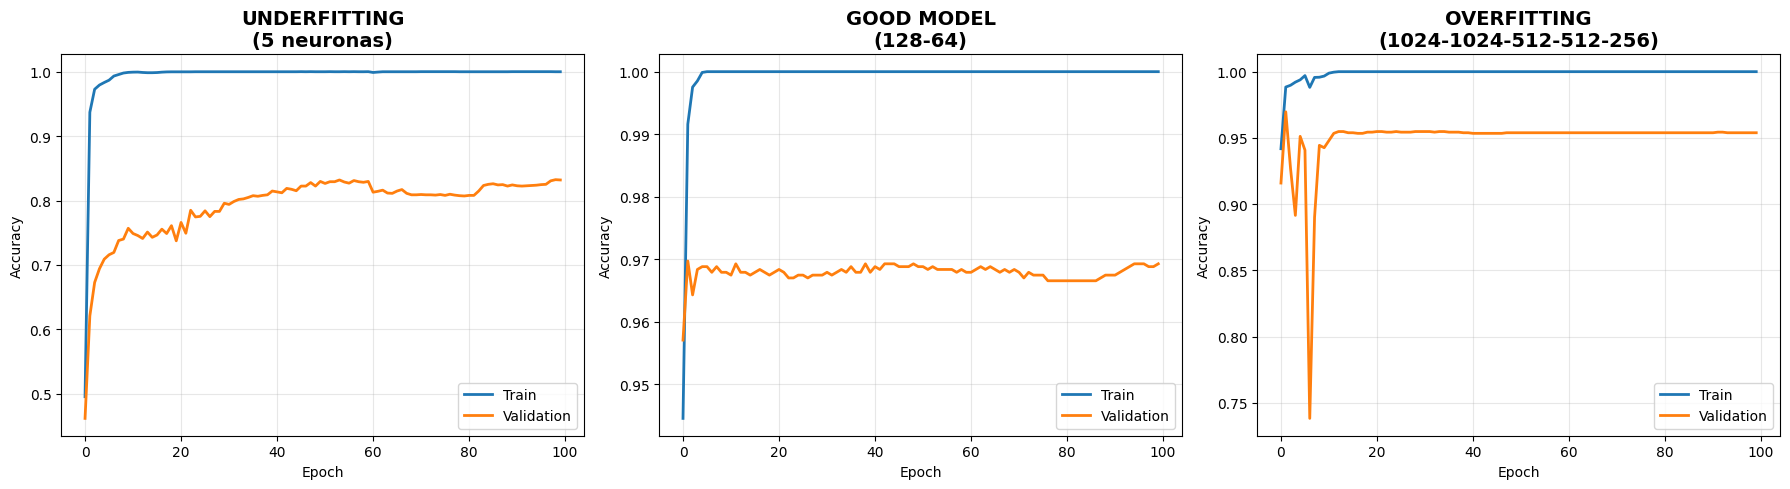

In [9]:
# 1. TRES MODELOS BASE: UNDERFITTING, GOOD, OVERFITTING

print("\n" + "="*80)
print("PARTE 1: MODELOS SIN REGULARIZACIÓN")
print("="*80)

# 1.1 UNDERFITTING EXTREMO
print("\n[1/3] Entrenando modelo UNDERFITTING...")
model_underfit = tf.keras.Sequential([
    layers.Dense(5, activation='relu', input_shape=(input_dim,)),
    layers.Dense(num_classes, activation='softmax')
])
model_underfit.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_underfit = model_underfit.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_underfit.history['accuracy'][-1]:.4f} | Val: {history_underfit.history['val_accuracy'][-1]:.4f}")

# 1.2 GOOD MODEL
print("\n[2/3] Entrenando modelo GOOD...")
model_good = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model_good.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_good = model_good.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_good.history['accuracy'][-1]:.4f} | Val: {history_good.history['val_accuracy'][-1]:.4f}")

# 1.3 OVERFITTING EXTREMO
print("\n[3/3] Entrenando modelo OVERFITTING...")
model_overfit = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model_overfit.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_overfit = model_overfit.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_overfit.history['accuracy'][-1]:.4f} | Val: {history_overfit.history['val_accuracy'][-1]:.4f}")

# Gráficos de los 3 modelos base
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_underfit.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_underfit.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('UNDERFITTING\n(5 neuronas)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_good.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history_good.history['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_title('GOOD MODEL\n(128-64)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history_overfit.history['accuracy'], label='Train', linewidth=2)
axes[2].plot(history_overfit.history['val_accuracy'], label='Validation', linewidth=2)
axes[2].set_title('OVERFITTING\n(1024-1024-512-512-256)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


PARTE 2: TÉCNICAS DE REGULARIZACIÓN (sobre arquitectura de overfitting)

[1/8] Entrenando con L1...
   Train: 1.0000 | Val: 0.9729

[2/8] Entrenando con L2...
   Train: 0.9979 | Val: 0.9634

[3/8] Entrenando con L1+L2...
   Train: 0.9988 | Val: 0.9751

[4/8] Entrenando con Dropout...
   Train: 0.9993 | Val: 0.9354

[5/8] Entrenando con Batch Normalization...
   Train: 1.0000 | Val: 0.8970

[6/8] Entrenando con Early Stopping...
   Train: 0.9973 | Val: 0.7592 | Paró en epoch 16

[7/8] Entrenando con L2+Dropout...
   Train: 0.9944 | Val: 0.9693

[8/8] Entrenando con L2+Dropout+BatchNorm...
   Train: 0.9895 | Val: 0.9629


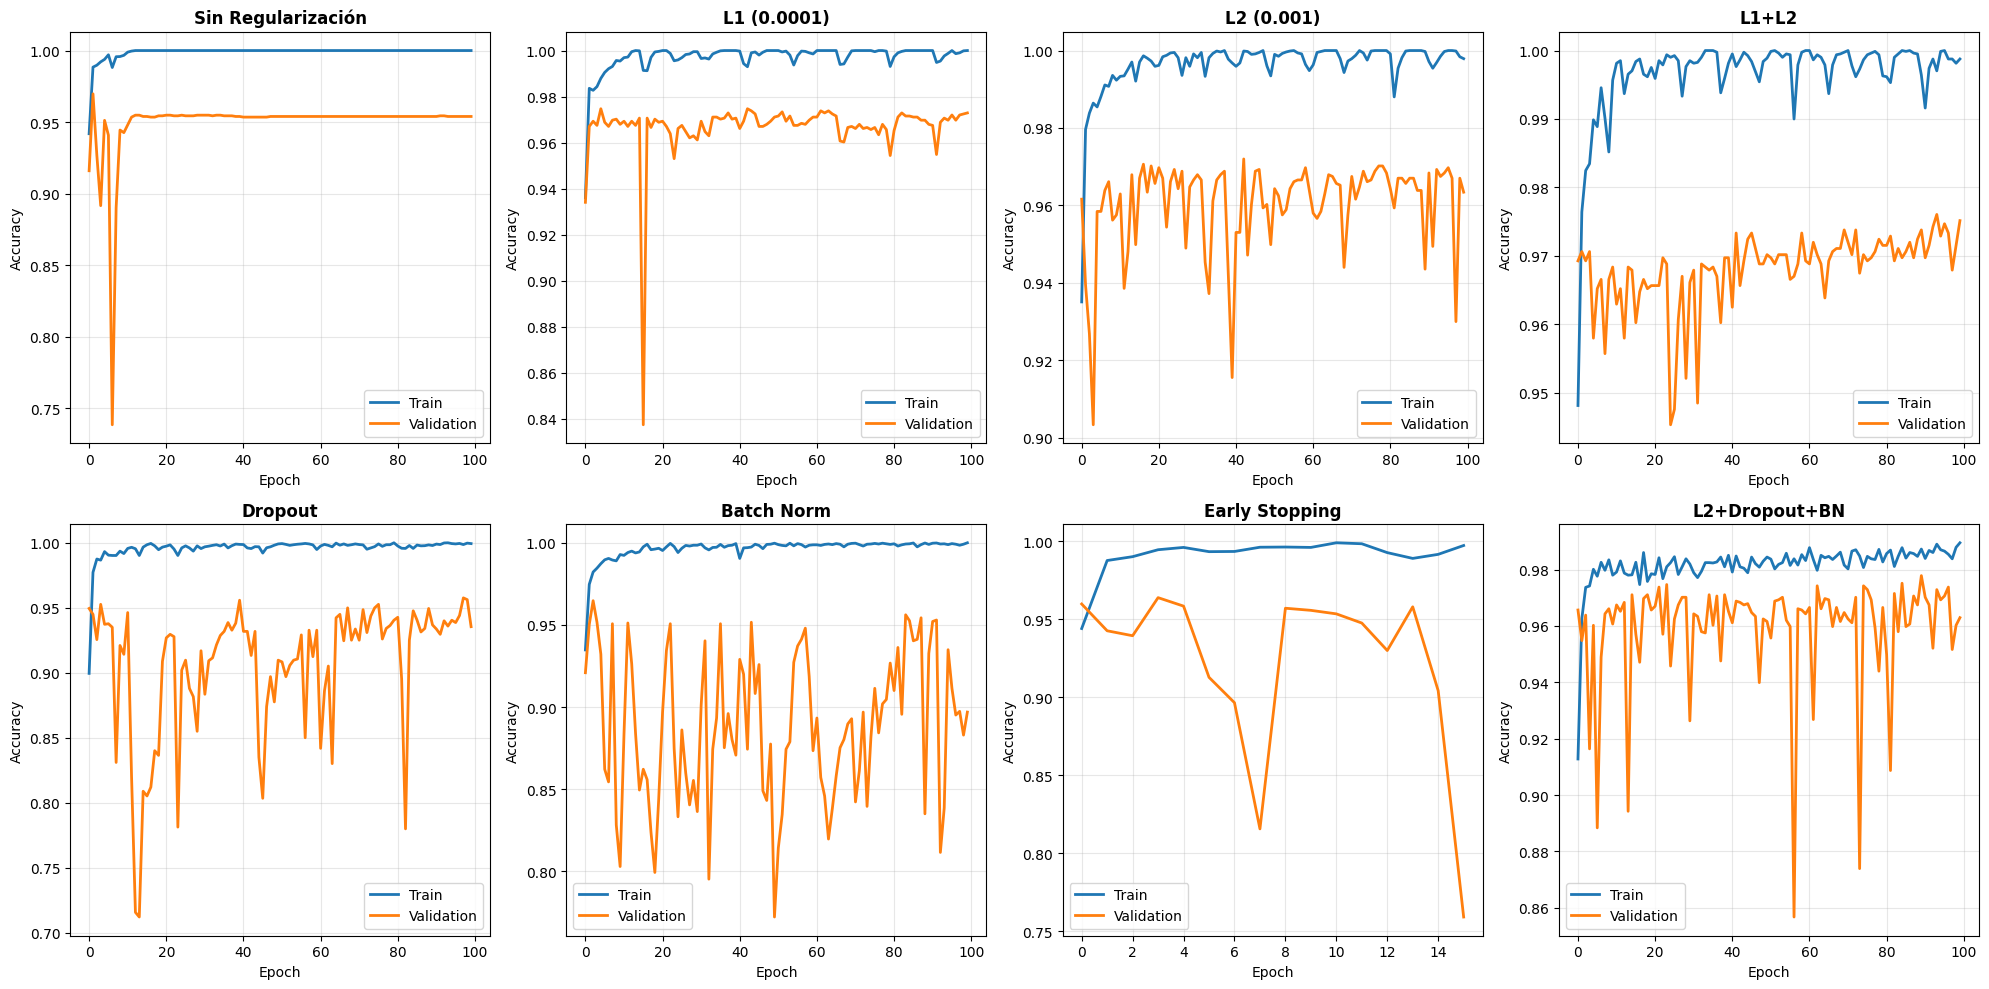

In [10]:
# 2. TÉCNICAS DE REGULARIZACIÓN

print("\n" + "="*80)
print("PARTE 2: TÉCNICAS DE REGULARIZACIÓN (sobre arquitectura de overfitting)")
print("="*80)

# 2.1 L1
print("\n[1/8] Entrenando con L1...")
model_l1 = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l1(0.0001), input_shape=(input_dim,)),
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    layers.Dense(num_classes, activation='softmax')
])
model_l1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_l1 = model_l1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_l1.history['accuracy'][-1]:.4f} | Val: {history_l1.history['val_accuracy'][-1]:.4f}")

# 2.2 L2
print("\n[2/8] Entrenando con L2...")
model_l2 = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(input_dim,)),
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(num_classes, activation='softmax')
])
model_l2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_l2 = model_l2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_l2.history['accuracy'][-1]:.4f} | Val: {history_l2.history['val_accuracy'][-1]:.4f}")

# 2.3 L1+L2 (ElasticNet)
print("\n[3/8] Entrenando con L1+L2...")
model_l1l2 = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001), input_shape=(input_dim,)),
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)),
    layers.Dense(num_classes, activation='softmax')
])
model_l1l2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_l1l2 = model_l1l2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_l1l2.history['accuracy'][-1]:.4f} | Val: {history_l1l2.history['val_accuracy'][-1]:.4f}")

# 2.4 Dropout
print("\n[4/8] Entrenando con Dropout...")
model_dropout = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.4),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])
model_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_dropout = model_dropout.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_dropout.history['accuracy'][-1]:.4f} | Val: {history_dropout.history['val_accuracy'][-1]:.4f}")

# 2.5 Batch Normalization
print("\n[5/8] Entrenando con Batch Normalization...")
model_bn = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(num_classes, activation='softmax')
])
model_bn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_bn = model_bn.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_bn.history['accuracy'][-1]:.4f} | Val: {history_bn.history['val_accuracy'][-1]:.4f}")

# 2.6 Early Stopping
print("\n[6/8] Entrenando con Early Stopping...")
model_early = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model_early.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
history_early = model_early.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)
print(f"   Train: {history_early.history['accuracy'][-1]:.4f} | Val: {history_early.history['val_accuracy'][-1]:.4f} | Paró en epoch {len(history_early.history['loss'])}")

# 2.7 L2 + Dropout
print("\n[7/8] Entrenando con L2+Dropout...")
model_l2_dropout = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.0005), input_shape=(input_dim,)),
    layers.Dropout(0.3),
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.25),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.25),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])
model_l2_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_l2_dropout = model_l2_dropout.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_l2_dropout.history['accuracy'][-1]:.4f} | Val: {history_l2_dropout.history['val_accuracy'][-1]:.4f}")

# 2.8 L2 + Dropout + Batch Normalization
print("\n[8/8] Entrenando con L2+Dropout+BatchNorm...")
model_combined = tf.keras.Sequential([
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.0005), input_shape=(input_dim,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])
model_combined.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_combined = model_combined.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, verbose=0)
print(f"   Train: {history_combined.history['accuracy'][-1]:.4f} | Val: {history_combined.history['val_accuracy'][-1]:.4f}")

# Gráficos de todas las regularizaciones
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

histories = [
    (history_overfit, 'Sin Regularización'),
    (history_l1, 'L1 (0.0001)'),
    (history_l2, 'L2 (0.001)'),
    (history_l1l2, 'L1+L2'),
    (history_dropout, 'Dropout'),
    (history_bn, 'Batch Norm'),
    (history_early, 'Early Stopping'),
    (history_combined, 'L2+Dropout+BN')
]

for idx, (history, title) in enumerate(histories):
    axes[idx].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[idx].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# 3. TABLA COMPARATIVA Y MEJOR MODELO

print("\n" + "="*80)
print("TABLA RESUMEN")
print("="*80)

models_eval = [
    (model_underfit, history_underfit, 'Underfitting'),
    (model_good, history_good, 'Good Model'),
    (model_overfit, history_overfit, 'Overfitting'),
    (model_l1, history_l1, 'L1'),
    (model_l2, history_l2, 'L2'),
    (model_l1l2, history_l1l2, 'L1+L2'),
    (model_dropout, history_dropout, 'Dropout'),
    (model_bn, history_bn, 'Batch Norm'),
    (model_early, history_early, 'Early Stop'),
    (model_l2_dropout, history_l2_dropout, 'L2+Dropout'),
    (model_combined, history_combined, 'L2+Drop+BN')
]

print(f"{'Modelo':<20} {'Train':>10} {'Val':>10} {'Gap':>10}")
print("-" * 55)

best_val = 0
best_model = None
best_name = ""

for model, history, name in models_eval:
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = abs(train_acc - val_acc)
    print(f"{name:<20} {train_acc:>10.4f} {val_acc:>10.4f} {gap:>10.4f}")
    
    if val_acc > best_val:
        best_val = val_acc
        best_model = model
        best_name = name

print(f"\n MEJOR MODELO: {best_name} (Val Acc: {best_val:.4f})")


TABLA RESUMEN
Modelo                    Train        Val        Gap
-------------------------------------------------------
Underfitting             0.9999     0.8319     0.1680
Good Model               1.0000     0.9693     0.0307
Overfitting              1.0000     0.9539     0.0461
L1                       1.0000     0.9729     0.0271
L2                       0.9979     0.9634     0.0345
L1+L2                    0.9988     0.9751     0.0236
Dropout                  0.9993     0.9354     0.0639
Batch Norm               1.0000     0.8970     0.1030
Early Stop               0.9973     0.7592     0.2381
L2+Dropout               0.9944     0.9693     0.0252
L2+Drop+BN               0.9895     0.9629     0.0266

 MEJOR MODELO: L1+L2 (Val Acc: 0.9751)


In [15]:
# 4. EVALUACIÓN EN TEST FINAL

print("\n" + "="*80)
print("EVALUACIÓN EN TEST FINAL")
print("="*80)

test_loss, test_acc = best_model.evaluate(X_test_final, y_test_final, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred = best_model.predict(X_test_final, verbose=0)
y_pred_classes = y_pred.argmax(axis=1)
y_test_classes = y_test_final.argmax(axis=1)

print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=label_encoder.classes_))


EVALUACIÓN EN TEST FINAL

Test Accuracy: 0.9723
Test Loss: 0.2211

Classification Report:
                             precision    recall  f1-score   support

                     B cell       0.99      1.00      0.99       821
                 CD4 T cell       0.97      0.98      0.97      1528
                 CD8 T cell       0.95      0.94      0.94       746
    Hematopoietic stem cell       0.62      1.00      0.77         5
              Megakaryocyte       0.97      0.75      0.85        40
              Monocyte_CD14       0.98      0.98      0.98      1523
            Monocyte_FCGR3A       0.96      0.95      0.95       249
                    NK cell       0.97      0.99      0.98       203
Plasmacytoid dendritic cell       1.00      1.00      1.00        50

                   accuracy                           0.97      5165
                  macro avg       0.93      0.95      0.94      5165
               weighted avg       0.97      0.97      0.97      5165

